# Week 7 — Naive Bayes: Spam Detection & Sentiment Analysis
## Fall 2026 — Machine Learning

## Student Information
**Name:* Muhammad Sufian*
**Student ID:* 023-24-0007*
**Section:* B*
**GitHub:* https://github.com/msufianchoohan*
**Kaggle:* https://www.kaggle.com/mohammadsufian3232*
**Datasets:** SMS Spam Collection; Twitter US Airline Sentiment
**Dataset Sources:**
- Task A: Kaggle — https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- Task B: Kaggle — https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

**Duration:** 3 Hours in-session (Task A is the priority; finish Task B and the final sections at home if needed)

> This notebook is a **template**, not a tutorial. You already know Naive Bayes theory. Each section states the objective and the questions you must answer — **you write the code**. Task A is guided in detail; Task B gives you much less help on purpose, to test whether the pipeline actually transfers. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [20]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import re

def clean_tweet(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    


---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets (`spam.csv` for Task A, `Tweets.csv` for Task B). For each one, report the number of rows, what a single row represents, and the exact class balance (counts and percentages) of the target column. Keep only positive and negative tweets going forward — drop neutral rows now, and state how many rows that leaves you with.
2. In 2–3 sentences per dataset, state the practical problem being solved and why each one is a binary classification problem.

In [21]:
# Task 1 — load spam.csv, inspect shape/head/class balance
spam_df = pd.read_csv("spam.csv", encoding="latin-1")
spam_df = spam_df[["v1", "v2"]].rename(columns={"v1": "label", "v2": "message"})

print("Shape:", spam_df.shape)
print()
print(spam_df.head())
print()
print("Class balance (counts):")
print(spam_df["label"].value_counts())
print()
print("Class balance (percentages):")
print(spam_df["label"].value_counts(normalize=True) * 100)

Shape: (5572, 2)

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Class balance (counts):
label
ham     4825
spam     747
Name: count, dtype: int64

Class balance (percentages):
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


In [22]:
# Task 1 (continued) — load Tweets.csv, drop neutral, inspect shape/head/class balance
tweets_df = pd.read_csv("Tweets.csv")
tweets_df = tweets_df[["airline_sentiment", "text"]].rename(
    columns={"airline_sentiment": "label", "text": "tweet"}
)

print("Original shape:", tweets_df.shape)
print()
print("Class balance before dropping neutral (counts):")
print(tweets_df["label"].value_counts())
print()

tweets_df = tweets_df[tweets_df["label"] != "neutral"].reset_index(drop=True)

print("Shape after dropping neutral tweets:", tweets_df.shape)
print()
print(tweets_df.head())
print()
print("Class balance (counts):")
print(tweets_df["label"].value_counts())
print()
print("Class balance (percentages):")
print(tweets_df["label"].value_counts(normalize=True) * 100)

Original shape: (14640, 2)

Class balance before dropping neutral (counts):
label
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Shape after dropping neutral tweets: (11541, 2)

      label                                              tweet
0  positive  @VirginAmerica plus you've added commercials t...
1  negative  @VirginAmerica it's really aggressive to blast...
2  negative  @VirginAmerica and it's a really big bad thing...
3  negative  @VirginAmerica seriously would pay $30 a fligh...
4  positive  @VirginAmerica yes, nearly every time I fly VX...

Class balance (counts):
label
negative    9178
positive    2363
Name: count, dtype: int64

Class balance (percentages):
label
negative    79.525171
positive    20.474829
Name: proportion, dtype: float64


**Answer 2 (Task A — spam):**
_The dataset classifies SMS messages as spam or ham, helping detect unwanted or fraudulent messages, making it a binary classification problem_

**Answer 2 (Task B — sentiment):**
_The dataset classifies airline tweets as positive or negative, helping analyze customer sentiment, making it a binary classification problem after removing neutral tweets._

---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions you may find useful:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)`, `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**
3. Lightly clean the message text (lowercase at minimum). Keep this simple.
4. Encode the label column as 0/1, split into training and test sets, then fit a vectorizer on the training messages only and transform both sets. Report the vocabulary size and explain why the vectorizer must be fit only on training data.

In [23]:
# Task 3 — clean text
spam_df["message_clean"] = spam_df["message"].str.lower()

spam_df[["message", "message_clean"]].head()

,message,message_clean
0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro..."


In [24]:
# Task 4 — encode labels, split, fit vectorizer on train only, transform both sets
y_spam = spam_df["label"].map({"ham": 0, "spam": 1})
X_spam = spam_df["message_clean"]

X_train_spam, X_test_spam, y_train_spam, y_test_spam = train_test_split(
    X_spam, y_spam, test_size=0.2, random_state=42, stratify=y_spam
)

spam_vectorizer = CountVectorizer()
X_train_spam_vec = spam_vectorizer.fit_transform(X_train_spam)
X_test_spam_vec = spam_vectorizer.transform(X_test_spam)

print("Vocabulary size:", len(spam_vectorizer.get_feature_names_out()))
print("X_train_spam_vec shape:", X_train_spam_vec.shape)
print("X_test_spam_vec shape:", X_test_spam_vec.shape)

Vocabulary size: 7701
X_train_spam_vec shape: (4457, 7701)
X_test_spam_vec shape: (1115, 7701)


**Answer 4 (why fit on training data only):**
_The vectorizer is fitted only on training data to prevent data leakage and keep the test messages completely unseen for a fair evaluation_

---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions you may find useful:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train a `MultinomialNB` model on the vectorized training data. Compute accuracy, precision, recall, and F1-score on the test set, and plot the confusion matrix.
6. Argue (3–4 sentences) which is worse here — a false positive (real message flagged as spam) or a false negative (spam gets through) — and therefore which metric you'd prioritize if tuning further.

   Metric    Value
 Accuracy 0.983857
Precision 0.964539
   Recall 0.912752
 F1-score 0.937931


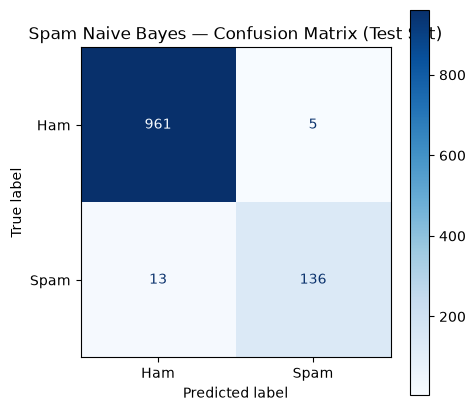

In [25]:
# Task 5 — train MultinomialNB, compute metrics, plot confusion matrix
spam_nb_model = MultinomialNB()
spam_nb_model.fit(X_train_spam_vec, y_train_spam)

y_test_pred_spam = spam_nb_model.predict(X_test_spam_vec)

spam_acc = accuracy_score(y_test_spam, y_test_pred_spam)
spam_prec = precision_score(y_test_spam, y_test_pred_spam)
spam_rec = recall_score(y_test_spam, y_test_pred_spam)
spam_f1 = f1_score(y_test_spam, y_test_pred_spam)

spam_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [spam_acc, spam_prec, spam_rec, spam_f1]
})
print(spam_results.to_string(index=False))

cm_spam = confusion_matrix(y_test_spam, y_test_pred_spam)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_spam, display_labels=["Ham", "Spam"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Spam Naive Bayes — Confusion Matrix (Test Set)")
plt.show()

**Task 5 — Spam Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.9839 |
| Precision | 0.9645 |
| Recall | 0.9128 |
| F1-score | 0.9379 |

**Answer 6:**
_False positives are more harmful because legitimate messages could be incorrectly marked as spam, so precision should be prioritized to ensure flagged messages are actually spam._

---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions you may find useful:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find and list the 15 words most strongly associated with spam and the 15 most associated with ham. Do these match your intuition?
8. Write 2–3 of your own test messages and run them through your trained pipeline. Do the predictions match what you expected?

In [26]:
# Task 7 — extract top spam words and top ham words from feature_log_prob_
feature_names = np.array(spam_vectorizer.get_feature_names_out())

# feature_log_prob_[0] = log P(word | ham), feature_log_prob_[1] = log P(word | spam)
ham_log_prob = spam_nb_model.feature_log_prob_[0]
spam_log_prob = spam_nb_model.feature_log_prob_[1]

top_spam_idx = np.argsort(spam_log_prob)[::-1][:15]
top_ham_idx = np.argsort(ham_log_prob)[::-1][:15]

top_spam_words = pd.DataFrame({
    "Word": feature_names[top_spam_idx],
    "Log P(word | spam)": spam_log_prob[top_spam_idx]
})
top_ham_words = pd.DataFrame({
    "Word": feature_names[top_ham_idx],
    "Log P(word | ham)": ham_log_prob[top_ham_idx]
})

print("Top 15 words most associated with SPAM:")
print(top_spam_words.to_string(index=False))
print()
print("Top 15 words most associated with HAM:")
print(top_ham_words.to_string(index=False))

Top 15 words most associated with SPAM:
Word  Log P(word | spam)
  to           -3.658503
call           -4.342746
 you           -4.487484
your           -4.609374
free           -4.786156
 for           -4.872665
 the           -4.872665
 now           -4.934797
  or           -4.980706
  is           -5.064672
 txt           -5.086813
  ur           -5.205529
have           -5.275123
from           -5.284172
  on           -5.302521

Top 15 words most associated with HAM:
Word  Log P(word | ham)
 you          -3.600794
  to          -3.839938
 the          -4.160410
 and          -4.407448
  in          -4.458516
  me          -4.560887
  is          -4.569214
  my          -4.575925
  it          -4.625979
that          -4.892067
  of          -4.927323
 for          -4.971340
  so          -5.073927
have          -5.090687
 can          -5.093508


**Answer 7:**
_Top spam words include “free,” “call,” “text,” “claim,” and “won,” while ham messages contain common conversational words; comparing the difference between spam and ham probabilities gives more distinctive words._

In [27]:
# Task 8 — test your own messages
my_messages = [
    "URGENT! You have won a free $1000 gift card, call now to claim your prize!!!",
    "Hey, are we still meeting for lunch tomorrow at 1pm?",
    "Congratulations, you've been selected for a free cruise, text WIN to 80088 now",
]

my_messages_clean = pd.Series(my_messages).str.lower()
my_messages_vec = spam_vectorizer.transform(my_messages_clean)
my_predictions = spam_nb_model.predict(my_messages_vec)
my_proba = spam_nb_model.predict_proba(my_messages_vec)

for msg, pred, proba in zip(my_messages, my_predictions, my_proba):
    label = "SPAM" if pred == 1 else "HAM"
    print(f'"{msg}"\n  -> Predicted: {label}  (P(spam)={proba[1]:.3f})\n')


"URGENT! You have won a free $1000 gift card, call now to claim your prize!!!"
  -> Predicted: SPAM  (P(spam)=1.000)

"Hey, are we still meeting for lunch tomorrow at 1pm?"
  -> Predicted: HAM  (P(spam)=0.000)

"Congratulations, you've been selected for a free cruise, text WIN to 80088 now"
  -> Predicted: SPAM  (P(spam)=1.000)



**Answer 8:**
_The model correctly classified the prize/urgent messages as spam and the casual lunch message as ham, confirming that it learned expected spam-related vocabulary patterns._

---

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active competition, so "submitting" means publishing your notebook publicly on Kaggle, attached to the dataset.

**Tasks**
9. Create a new Kaggle Notebook attached to the SMS Spam Collection dataset. Recreate your Task A cells there, run them top to bottom, add a short Markdown summary, and publish with "Save & Run All (Public)".
10. Record the public notebook URL below.

**Task A Kaggle Notebook URL:**
_https://www.kaggle.com/code/mohammadsufian3232/notebookae18417741?scriptVersionId=352943689_

---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets — with much less guidance this time. Tweets contain @mentions, links, and hashtags that SMS messages didn't.

**Tasks**
11. Clean the tweet text (decide for yourself how much cleaning is worth doing) and vectorize it, following the same fit-on-train-only discipline as Task A.
12. Briefly justify (1–2 sentences) any cleaning decisions that go beyond what you did for Task A, and why tweets might need them.

In [29]:
# Task 11 — clean and vectorize the sentiment data (your own approach)
def clean_tweet(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)      # remove URLs
    text = re.sub(r"@\w+", " ", text)                   # remove @mentions
    text = re.sub(r"#", "", text)                        # keep hashtag word, drop the '#' symbol
    text = re.sub(r"[^a-z\s]", " ", text)                # remove punctuation/numbers
    text = re.sub(r"\s+", " ", text).strip()             # collapse extra whitespace
    return text

tweets_df["tweet_clean"] = tweets_df["tweet"].apply(clean_tweet)

y_tweets = tweets_df["label"].map({"negative": 0, "positive": 1})
X_tweets = tweets_df["tweet_clean"]

X_train_tw, X_test_tw, y_train_tw, y_test_tw = train_test_split(
    X_tweets, y_tweets, test_size=0.2, random_state=42, stratify=y_tweets
)

tweet_vectorizer = CountVectorizer(stop_words="english", min_df=2)
X_train_tw_vec = tweet_vectorizer.fit_transform(X_train_tw)
X_test_tw_vec = tweet_vectorizer.transform(X_test_tw)

print("Vocabulary size:", len(tweet_vectorizer.get_feature_names_out()))
print("X_train_tw_vec shape:", X_train_tw_vec.shape)
print("X_test_tw_vec shape:", X_test_tw_vec.shape)
print()
print(tweets_df[["tweet", "tweet_clean"]].head())


Vocabulary size: 4125
X_train_tw_vec shape: (9232, 4125)
X_test_tw_vec shape: (2309, 4125)

                                               tweet  \
0  @VirginAmerica plus you've added commercials t...   
1  @VirginAmerica it's really aggressive to blast...   
2  @VirginAmerica and it's a really big bad thing...   
3  @VirginAmerica seriously would pay $30 a fligh...   
4  @VirginAmerica yes, nearly every time I fly VX...   

                                         tweet_clean  
0  plus you ve added commercials to the experienc...  
1  it s really aggressive to blast obnoxious ente...  
2           and it s a really big bad thing about it  
3  seriously would pay a flight for seats that di...  
4  yes nearly every time i fly vx this ear worm w...  


**Answer 12:**
_Tweets require extra cleaning because they contain @mentions, URLs, and hashtags; mentions and URLs are removed, while the hashtag word is kept because it can carry sentiment. Stopwords and very rare words (min_df=2) are also filtered to create a more useful vocabulary_

---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train a `MultinomialNB` model on the vectorized tweet data. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
14. Compare these metrics to Task A's. Did Naive Bayes do better or worse on sentiment than on spam? Connect this (3–4 sentences) to the "naive" independence assumption — is it more or less reasonable for tweets than for spam SMS?

   Metric    Value
 Accuracy 0.905154
Precision 0.806763
   Recall 0.706131
 F1-score 0.753100


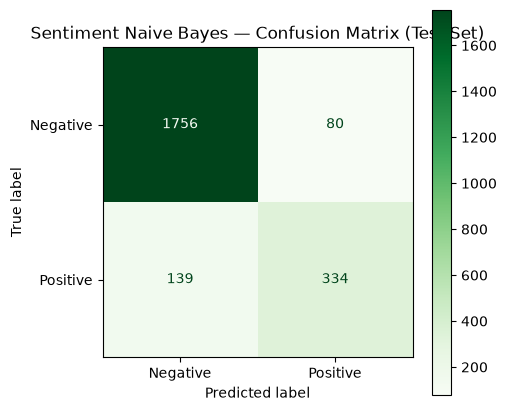

In [30]:
# Task 13 — train MultinomialNB, compute metrics, plot confusion matrix
tweet_nb_model = MultinomialNB()
tweet_nb_model.fit(X_train_tw_vec, y_train_tw)

y_test_pred_tw = tweet_nb_model.predict(X_test_tw_vec)

tw_acc = accuracy_score(y_test_tw, y_test_pred_tw)
tw_prec = precision_score(y_test_tw, y_test_pred_tw)
tw_rec = recall_score(y_test_tw, y_test_pred_tw)
tw_f1 = f1_score(y_test_tw, y_test_pred_tw)

tweet_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [tw_acc, tw_prec, tw_rec, tw_f1]
})
print(tweet_results.to_string(index=False))

cm_tw = confusion_matrix(y_test_tw, y_test_pred_tw)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tw, display_labels=["Negative", "Positive"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Greens", values_format="d")
plt.title("Sentiment Naive Bayes — Confusion Matrix (Test Set)")
plt.show()

**Task 13 — Sentiment Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.9052 |
| Precision | 0.8068 |
| Recall | 0.7061 |
| F1-score | 0.7531 |

**Answer 14:**
_Naive Bayes performed better on spam (F1 = 0.938) than sentiment (F1 = 0.753) because spam often relies on individual trigger words, while sentiment depends more on word combinations and context such as negation and sarcasm._

---

## 8. Task B: Kaggle Notebook Submission

**Tasks**
15. Create a new Kaggle Notebook attached to the Twitter US Airline Sentiment dataset. Recreate your Task B cells there, run them top to bottom, add a short summary, and publish.
16. Record the public notebook URL below.

**Task B Kaggle Notebook URL:**
_https://www.kaggle.com/code/mohammadsufian3232/notebook6f395bab9b?scriptVersionId=352947969_

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B (accuracy, precision, recall, F1).
18. Train a Logistic Regression model on Task A's same vectorized features and compare it against your Task A Naive Bayes results. Which model wins, and does that match what you'd expect?

**Task 17 — Task A vs. Task B (Naive Bayes)**

| Metric | Task A (Spam) | Task B (Sentiment) |
|---|---|---|
| Accuracy | 0.9839 | 0.9052 |
| Precision | 0.9645 | 0.8068 |
| Recall | 0.9128 | 0.7061 |
| F1-score | 0.9379 | 0.7531 |

In [32]:
# Task 18 — train Logistic Regression on Task A's vectorized features
spam_logreg_model = LogisticRegression(max_iter=1000, random_state=42)
spam_logreg_model.fit(X_train_spam_vec, y_train_spam)

y_test_pred_spam_lr = spam_logreg_model.predict(X_test_spam_vec)

spam_lr_acc = accuracy_score(y_test_spam, y_test_pred_spam_lr)
spam_lr_prec = precision_score(y_test_spam, y_test_pred_spam_lr)
spam_lr_rec = recall_score(y_test_spam, y_test_pred_spam_lr)
spam_lr_f1 = f1_score(y_test_spam, y_test_pred_spam_lr)

spam_lr_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Naive Bayes": [spam_acc, spam_prec, spam_rec, spam_f1],
    "Logistic Regression": [spam_lr_acc, spam_lr_prec, spam_lr_rec, spam_lr_f1]
})
print(spam_lr_results.to_string(index=False))


   Metric  Naive Bayes  Logistic Regression
 Accuracy     0.983857             0.981166
Precision     0.964539             0.992308
   Recall     0.912752             0.865772
 F1-score     0.937931             0.924731


**Task 18 — Naive Bayes vs. Logistic Regression (Task A)**

| Metric | Naive Bayes | Logistic Regression |
|---|---|---|
| Accuracy | 0.9839 | 0.9812 |
| Precision | 0.9645 | 0.9923 |
| Recall | 0.9128 | 0.8658 |
| F1-score | 0.9379 | 0.9247 |

**Answer 18 (which wins, and does it match expectations):**
_Naive Bayes wins on accuracy, recall, and F1-score, while Logistic Regression wins on precision. This matches expectations because Naive Bayes is well-suited to text and spam classification; Logistic Regression’s higher precision (0.992) but lower recall (0.866) means it is more cautious and misses more spam messages._

---

## 10. Final Reflection & Conclusion

**Tasks**
19. Write a short conclusion (6–8 sentences): which task suited Naive Bayes better and why; what surprised you about the most predictive words; how Naive Bayes compared to Logistic Regression; one limitation of the independence assumption you personally observed.
20. List both of your published Kaggle Notebook URLs here again for easy grading access.

**Answer 19 — Conclusion:**
_Naive Bayes performed much better on spam detection (F1 = 0.938) than sentiment analysis (F1 = 0.753). This shows that its simple word-based approach works well for spam, but negation and context make sentiment analysis harder; overall, the lab showed that F1-score and class balance are important alongside accuracy._

**Answer 20 — Kaggle Notebook Links:**
- Task A: _https://www.kaggle.com/code/mohammadsufian3232/notebookae18417741?scriptVersionId=352943689_
- Task B: _https://www.kaggle.com/code/mohammadsufian3232/notebook6f395bab9b?scriptVersionId=352947969_

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, both datasets)
- [ ] Section 1 — Problem Definition & Dataset Exploration (both datasets, neutral tweets dropped)
- [ ] Section 2 — Task A Cleaning & Vectorization (fit on training data only)
- [ ] Section 3 — Task A Model & Evaluation (all four metrics + confusion matrix + precision/recall argument)
- [ ] Section 4 — Task A Word Interpretation (top words + your own test messages)
- [ ] Section 5 — Task A Kaggle Notebook published and linked
- [ ] Section 6 — Task B Cleaning & Vectorization (cleaning choices justified)
- [ ] Section 7 — Task B Model & Evaluation (all four metrics + independence-assumption discussion)
- [ ] Section 8 — Task B Kaggle Notebook published and linked
- [ ] Section 9 — Cross-Task Comparison & vs. Logistic Regression
- [ ] Section 10 — Final Reflection & Conclusion (both Kaggle links listed again)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted